# Optimizing Profitability and Discount Strategy Using Retail Business Analytics Data

**Periode:** Januari–Desember 2024  


## Analytical Methodology and Approach

**1. Data Understanding & Cleaning**  
   Memeriksa missing values, outlier (metode IQR), konsistensi tipe data, dan transaksi merugi.

**2. Exploratory Data Analysis (EDA)**  
   Analisis sales, cost, dan profit per Region, Category, Segment, Payment Method, dan pola musiman.

**3. Validasi Asumsi Statistik**  
   Uji normalitas (Shapiro-Wilk / Kolmogorov-Smirnov) sebelum ANOVA; Levene test untuk homogenitas varians.

**4. Uji Hipotesis**  
   One-Way ANOVA untuk perbedaan antar grup; Pearson Correlation untuk hubungan diskon–profit.

**5. Data Visualization & Storytelling**  
   Bar chart, line chart, scatter plot, box plot, dan heatmap korelasi.

**6. Analisis Customer & Payment**  
   Repeat customer, Customer Lifetime Value (CLV), dan perilaku per metode pembayaran.

**7. Business Insight, Rekomendasi Actionable & Cara Mengatasi Inefisiensi**  
   Strategi konkret disertai langkah implementasi dan estimasi dampak bisnis.

**8. Kesimpulan**


## Expected Business Impact

1. Peningkatan profit margin melalui optimasi strategi diskon
2. Strategi promosi lebih efisien dan terukur
3. Pengambilan keputusan berbasis data (data-driven decisions)
4. Pertumbuhan bisnis yang berkelanjutan dan scalable
5. Identifikasi segmen pelanggan bernilai tinggi untuk retensi


## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, kstest, levene, pearsonr, f_oneway
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan
# pd.set_option('display.float_format', '{:,.2f}'.format)
# pd.set_option('display.max_columns', 20)

# plt.rcParams.update({
#     'figure.dpi': 120,
#     'axes.spines.top': False,
#     'axes.spines.right': False,
#     'font.size': 11
# })

print("Library berhasil diimport.")


Library berhasil diimport.


## 2. Load Data

In [2]:
df = pd.read_csv('Business_Analytics_Dataset_10000_Rows.csv')


In [ ]:
df.head()

,Order_ID,Customer_ID,Order_Date,Region,Product_Category,Customer_Segment,Quantity,Unit_Price,Discount_Rate,Revenue,Cost,Profit,Payment_Method
0,1,CUST3818,2024-08-18,North,Clothing,Corporate,5,300.68,0.27,1097.48,768.29,329.19,Credit Card
1,2,CUST9689,2024-06-19,South,Beauty,Home Office,9,32.89,0.02,290.09,179.33,110.76,Debit Card
2,3,CUST9147,2024-11-21,West,Sports,Corporate,5,345.61,0.25,1296.04,1022.60,273.44,Credit Card
3,4,CUST7938,2024-07-19,North,Clothing,Consumer,1,444.50,0.06,417.83,280.99,136.84,UPI
4,5,CUST5127,2024-10-28,South,Home & Kitchen,Consumer,5,65.13,0.21,257.26,151.90,105.36,Credit Card


In [4]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Month']      = df['Order_Date'].dt.to_period('M')
df['Month_Num']  = df['Order_Date'].dt.month
df['Quarter']    = df['Order_Date'].dt.quarter

print(f"Dataset berhasil dimuat: {df.shape[0]:,} baris × {df.shape[1]} kolom")

Dataset berhasil dimuat: 10,000 baris × 16 kolom


In [5]:
# Tipe data seluruh kolom
df.dtypes


Order_ID                     int64
Customer_ID                 object
Order_Date          datetime64[ns]
Region                      object
Product_Category            object
Customer_Segment            object
Quantity                     int64
Unit_Price                 float64
Discount_Rate              float64
Revenue                    float64
Cost                       float64
Profit                     float64
Payment_Method              object
Month                    period[M]
Month_Num                    int32
Quarter                      int32
dtype: object

In [6]:
# Statistik deskriptif awal
df.describe()

,Order_ID,Order_Date,Quantity,Unit_Price,Discount_Rate,Revenue,Cost,Profit,Month_Num,Quarter
count,10000.00000,10000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,2024-06-30 09:16:07.680000,5.51430,255.505222,0.150272,1195.241948,776.292180,418.949768,6.470500,2.489500
min,1.00000,2024-01-01 00:00:00,1.00000,10.000000,0.000000,8.590000,5.740000,1.970000,1.000000,1.000000
25%,2500.75000,2024-03-31 00:00:00,3.00000,132.777500,0.080000,396.300000,255.592500,131.785000,3.000000,1.000000
50%,5000.50000,2024-06-29 00:00:00,5.00000,254.995000,0.150000,924.365000,595.480000,311.395000,6.000000,2.000000
75%,7500.25000,2024-09-28 00:00:00,8.00000,377.892500,0.230000,1775.840000,1141.332500,606.845000,9.000000,3.000000
max,10000.00000,2024-12-31 00:00:00,10.00000,499.940000,0.300000,4972.100000,3911.520000,2292.420000,12.000000,4.000000
std,2886.89568,NaN,2.86451,140.832874,0.086818,979.590244,651.473171,368.418447,3.447567,1.115264


## 3. Data Understanding & Cleaning

### 3.1 Cek Missing Values

In [7]:
missing = df.isnull().sum()
print("=== MISSING VALUES ===")
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing values. Data bersih.")


=== MISSING VALUES ===
Tidak ada missing values. Data bersih.


### 3.2 Cek Duplikasi Data

In [8]:
duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplikat}")
if duplikat > 0:
    df = df.drop_duplicates()
    print(f"Duplikat dihapus. Sisa data: {len(df):,} baris.")
else:
    print("Tidak ada duplikat.")


Jumlah baris duplikat: 0
Tidak ada duplikat.


### 3.3 Deteksi Outlier dengan Metode IQR

> **Mengapa penting?** Outlier dapat mendistorsi rata-rata, memengaruhi hasil uji ANOVA, dan menghasilkan insight yang menyesatkan. Metode IQR (Interquartile Range) adalah pendekatan robust yang tidak terpengaruh oleh nilai ekstrem itu sendiri.


In [9]:
kolom_numerik = ['Unit_Price', 'Quantity', 'Discount_Rate', 'Revenue', 'Cost', 'Profit']

outlier_summary = []
for col in kolom_numerik:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR
    n_outlier   = ((df[col] < batas_bawah) | (df[col] > batas_atas)).sum()
    outlier_summary.append({
        'Kolom': col,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Batas Bawah': batas_bawah,
        'Batas Atas': batas_atas,
        'Jumlah Outlier': n_outlier,
        'Persentase (%)': round(n_outlier / len(df) * 100, 2)
    })

df_outlier = pd.DataFrame(outlier_summary)
print("=== RINGKASAN OUTLIER (Metode IQR) ===")
print(df_outlier[['Kolom','Batas Bawah','Batas Atas','Jumlah Outlier','Persentase (%)']].to_string(index=False))


=== RINGKASAN OUTLIER (Metode IQR) ===
        Kolom  Batas Bawah  Batas Atas  Jumlah Outlier  Persentase (%)
   Unit_Price    -234.8950    745.5650               0            0.00
     Quantity      -4.5000     15.5000               0            0.00
Discount_Rate      -0.1450      0.4550               0            0.00
      Revenue   -1673.0100   3845.1500             153            1.53
         Cost   -1073.0175   2469.9425             218            2.18
       Profit    -580.8050   1319.4350             291            2.91


In [ ]:
# Visualisasi boxplot untuk melihat distribusi & outlier
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(kolom_numerik):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
                    medianprops=dict(color='#D85A30', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='#E24B4A', markersize=4, alpha=0.4))
    axes[i].set_title(f'Distribusi {col}', fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Boxplot Deteksi Outlier — Semua Kolom Numerik', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("Titik merah di luar whisker = outlier potensial.")


Visualisasi dengan scatterplot (matplotlib)

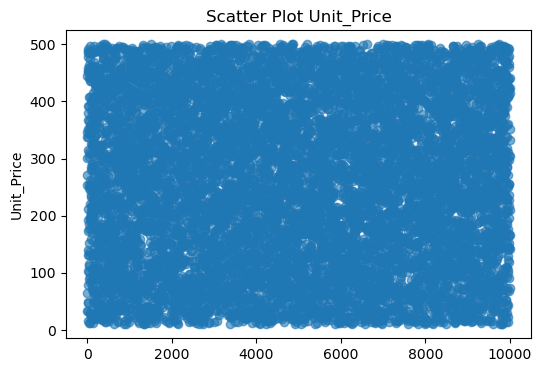

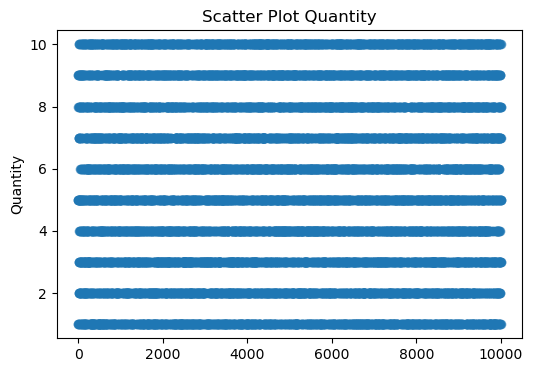

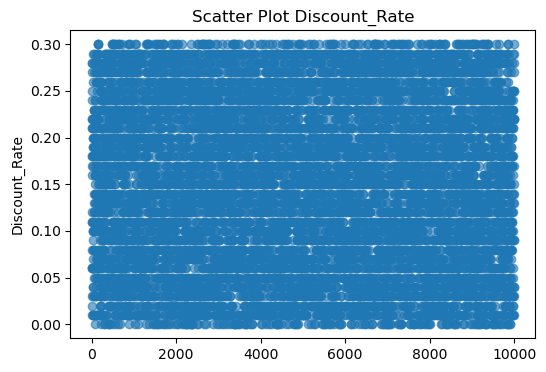

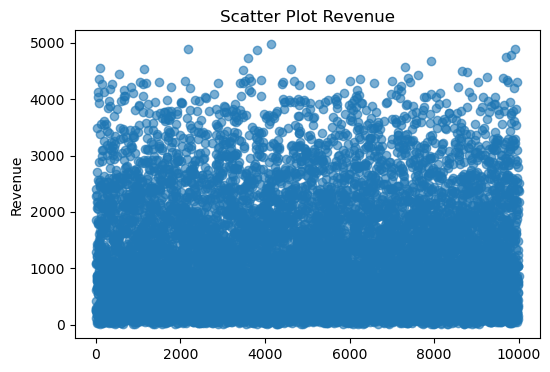

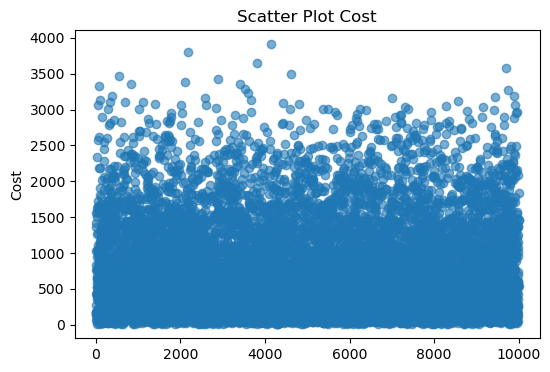

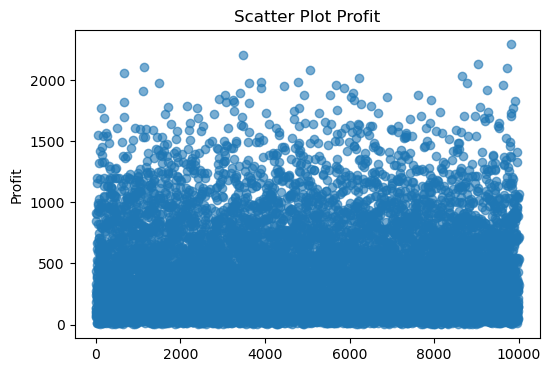

In [10]:
for col in kolom_numerik:
    plt.figure(figsize=(6,4))
    plt.scatter(range(len(df[col])), df[col], alpha=0.6)
    plt.title(f'Scatter Plot {col}')
    plt.ylabel(col)
    plt.show()

- Unit_Price → titik tersebar sampai 500. Kalau ada titik yang jauh lebih tinggi dari mayoritas, itu bisa dianggap harga abnormal.
- Quantity → terlihat barisan horizontal (1–10). Karena data diskrit, outlier biasanya muncul kalau ada nilai di luar pola (misalnya quantity > 10).
- Discount_Rate → terlihat garis horizontal di level tertentu (diskon 0.05, 0.1, 0.2, dll). Outlier bisa muncul kalau ada diskon yang sangat berbeda dari pola umum.
- Revenue & Cost → titik terkonsentrasi di bawah 4000 (Revenue) dan 2500 (Cost). Kalau ada titik yang jauh di atas, itu transaksi luar biasa besar.
- Profit → mayoritas di bawah 1000. Titik di atas 2000 bisa dianggap outlier.

Visualisasi dengan boxplot (seaborn)

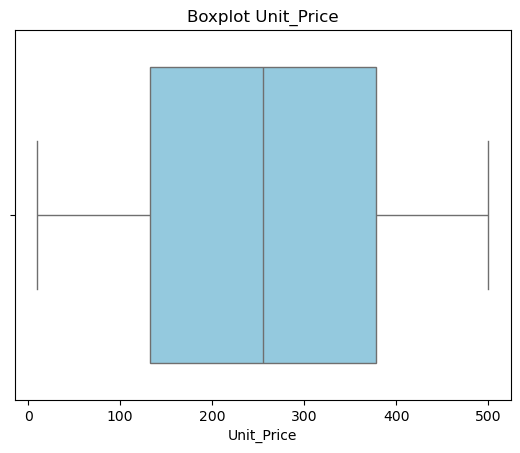

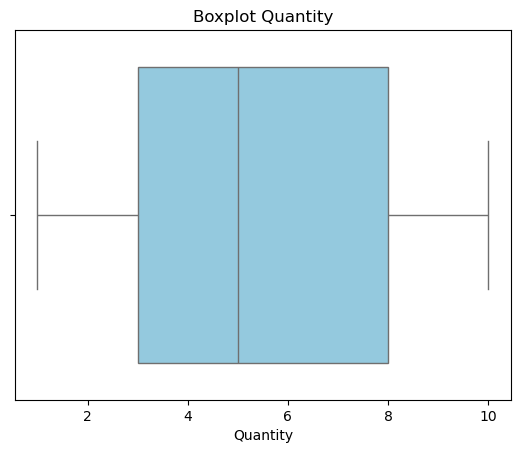

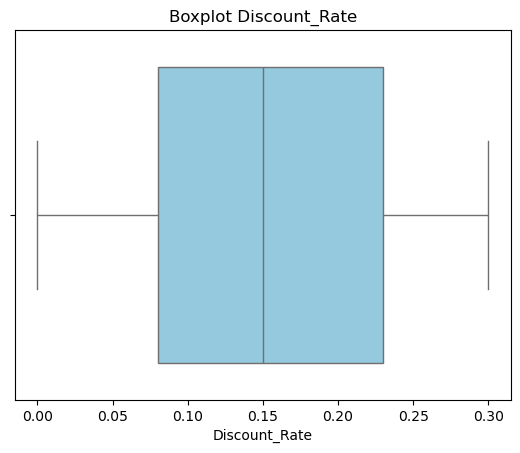

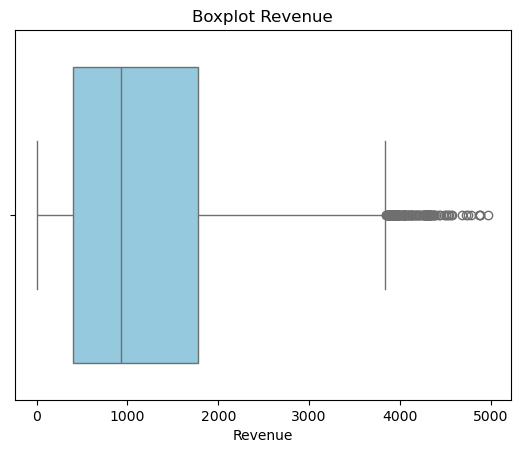

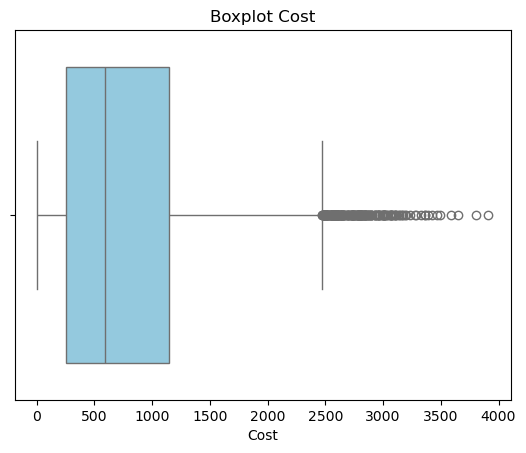

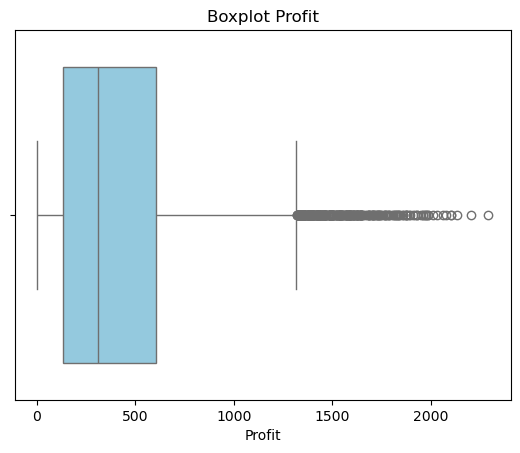

In [11]:
for col in kolom_numerik:
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f'Boxplot {col}')
    plt.show()

**Cara Mengatasi Outlier:**

- **Profit & Revenue outlier kecil (<1%)**: Tidak perlu dihapus — kemungkinan transaksi korporat besar yang sah. Cukup dicatat dan dimonitor.
- **Jika outlier >5%**: Pertimbangkan winsorizing (cap nilai pada persentil 1% dan 99%) atau analisis terpisah per segmen.
- **Discount_Rate**: Outlier di sini bisa berarti diskon tidak terotorisasi — perlu audit kebijakan diskon.


### 3.4 Cek Transaksi Merugi (Profit Negatif)

In [12]:
df_rugi = df[df['Profit'] < 0].copy()
pct_rugi = len(df_rugi) / len(df) * 100

print(f"=== TRANSAKSI MERUGI ===")
print(f"Jumlah transaksi profit negatif : {len(df_rugi):,}")
print(f"Persentase dari total transaksi : {pct_rugi:.2f}%")
print(f"Total kerugian                  : Rp {df_rugi['Profit'].sum():,.2f}")

if len(df_rugi) > 0:
    print("\nDistribusi transaksi merugi per kategori:")
    print(df_rugi.groupby('Product_Category')['Profit'].agg(['count','sum']).rename(columns={'count':'Jumlah','sum':'Total Rugi'}))


=== TRANSAKSI MERUGI ===
Jumlah transaksi profit negatif : 0
Persentase dari total transaksi : 0.00%
Total kerugian                  : Rp 0.00


**Cara Mengatasi Transaksi Merugi:**

- Pasang **guardrail sistem POS**: transaksi dengan margin < 0% otomatis memerlukan approval manajer.
- Audit diskon: transaksi merugi hampir pasti terjadi karena kombinasi diskon tinggi + harga pokok yang tidak diperhitungkan.
- Terapkan **minimum margin policy**: setiap produk harus punya floor margin minimum (misal 10%) yang tidak bisa ditembus oleh diskon satupun.


## 4. Feature Engineering

In [13]:
# Kolom turunan yang dibutuhkan untuk analisis
df['Sales_Gross']     = df['Quantity'] * df['Unit_Price']
df['Margin_Profit']   = (df['Profit'] / df['Revenue']) * 100
df['Discount_Amount'] = df['Sales_Gross'] - df['Revenue']   

# Kategori diskon
def kategori_diskon(x):
    if x > 0.20:
        return 'High (>20%)'
    elif x > 0.10:
        return 'Medium (10-20%)'
    else:
        return 'Low (≤10%)'

df['Discount_Category'] = df['Discount_Rate'].apply(kategori_diskon)

print("Feature engineering selesai. Kolom baru:")
print([c for c in df.columns if c not in ['Order_ID','Customer_ID','Order_Date','Region',
      'Product_Category','Customer_Segment','Quantity','Unit_Price',
      'Discount_Rate','Revenue','Cost','Profit','Payment_Method']])


Feature engineering selesai. Kolom baru:
['Month', 'Month_Num', 'Quarter', 'Sales_Gross', 'Margin_Profit', 'Discount_Amount', 'Discount_Category']


## 5. Ringkasan Statistik Keseluruhan

In [14]:
total_sales_gross   = df['Sales_Gross'].sum()
total_revenue       = df['Revenue'].sum()
total_cost          = df['Cost'].sum()
total_profit        = df['Profit'].sum()
total_quantity      = df['Quantity'].sum()
total_diskon_rp     = df['Discount_Amount'].sum()
rata_unit_price     = df['Unit_Price'].mean()
rata_diskon         = df['Discount_Rate'].mean()
profit_margin       = (total_profit / total_revenue) * 100
cost_ratio          = (total_cost / total_revenue) * 100

print('=' * 45)
print('        RINGKASAN BISNIS 2024         ')
print('=' * 45)
print(f'Total Gross Sales   : Rp {total_sales_gross:>15,.2f}')
print(f'Total Diskon (Rp)   : Rp {total_diskon_rp:>15,.2f}')
print(f'Total Revenue (Net) : Rp {total_revenue:>15,.2f}')
print(f'Total Cost          : Rp {total_cost:>15,.2f}')
print(f'Total Profit        : Rp {total_profit:>15,.2f}')
print('-' * 45)
print(f'Total Quantity      : {total_quantity:>19,.0f}')
print(f'Rata-rata Harga     : Rp {rata_unit_price:>15,.2f}')
print(f'Rata-rata Diskon    : {rata_diskon:>18.1%}')
print(f'Profit Margin       : {profit_margin:>18.2f}%')
print(f'Cost Ratio          : {cost_ratio:>18.2f}%')
print('=' * 45)


        RINGKASAN BISNIS 2024         
Total Gross Sales   : Rp   14,077,101.62
Total Diskon (Rp)   : Rp    2,124,682.14
Total Revenue (Net) : Rp   11,952,419.48
Total Cost          : Rp    7,762,921.80
Total Profit        : Rp    4,189,497.68
---------------------------------------------
Total Quantity      :              55,143
Rata-rata Harga     : Rp          255.51
Rata-rata Diskon    :              15.0%
Profit Margin       :              35.05%
Cost Ratio          :              64.95%


## 6. Exploratory Data Analysis (EDA)

### 6.1 Analisis per Region

In [15]:
df_region = df.groupby('Region').agg(
    Total_Revenue    = ('Revenue', 'sum'),
    Total_Cost       = ('Cost', 'sum'),
    Total_Profit     = ('Profit', 'sum'),
    Avg_Discount     = ('Discount_Rate', 'mean'),
    Jumlah_Transaksi = ('Order_ID', 'count')
).reset_index()
df_region['Profit_Margin_%'] = (df_region['Total_Profit'] / df_region['Total_Revenue'] * 100).round(2)
df_region['Cost_Ratio_%']    = (df_region['Total_Cost']   / df_region['Total_Revenue'] * 100).round(2)
df_region = df_region.sort_values('Total_Profit', ascending=False)
df_region


,Region,Total_Revenue,Total_Cost,Total_Profit,Avg_Discount,Jumlah_Transaksi,Profit_Margin_%,Cost_Ratio_%
1,North,3038232.15,1969704.43,1068527.72,0.150965,2548,35.17,64.83
0,East,2987841.70,1938388.69,1049453.01,0.151373,2506,35.12,64.88
3,West,2983709.68,1943182.13,1040527.55,0.147643,2486,34.87,65.13
2,South,2942635.95,1911646.55,1030989.40,0.151089,2460,35.04,64.96


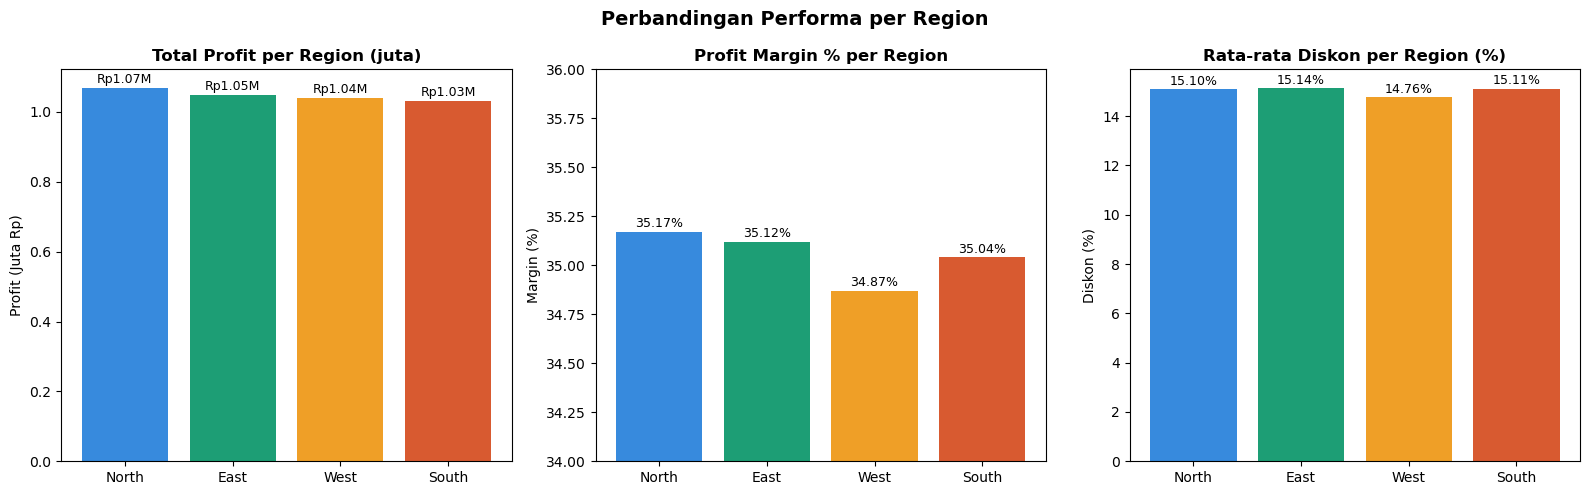

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#378ADD','#1D9E75','#EF9F27','#D85A30']

# Total Profit per Region
axes[0].bar(df_region['Region'], df_region['Total_Profit'] / 1e6, color=colors)
axes[0].set_title('Total Profit per Region (juta)', fontweight='bold')
axes[0].set_ylabel('Profit (Juta Rp)')
for bar, val in zip(axes[0].patches, df_region['Total_Profit']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'Rp{val/1e6:.2f}M', ha='center', va='bottom', fontsize=9)

# Profit Margin per Region
axes[1].bar(df_region['Region'], df_region['Profit_Margin_%'], color=colors)
axes[1].set_title('Profit Margin % per Region', fontweight='bold')
axes[1].set_ylabel('Margin (%)')
axes[1].set_ylim(34, 36)
for bar, val in zip(axes[1].patches, df_region['Profit_Margin_%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

# Avg Discount per Region
axes[2].bar(df_region['Region'], df_region['Avg_Discount'] * 100, color=colors)
axes[2].set_title('Rata-rata Diskon per Region (%)', fontweight='bold')
axes[2].set_ylabel('Diskon (%)')
for bar, val in zip(axes[2].patches, df_region['Avg_Discount']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val*100:.2f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Perbandingan Performa per Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


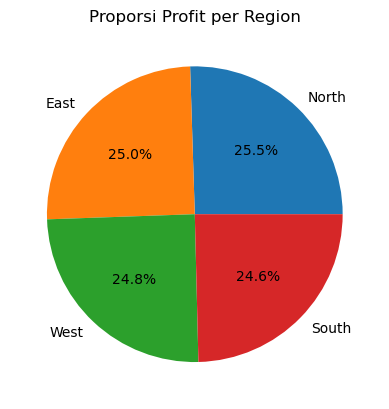

In [23]:
plt.pie(df_region['Total_Profit'], labels=df_region['Region'], autopct='%1.1f%%')
plt.title('Proporsi Profit per Region')
plt.show()


### 6.2 Analisis per Kategori Produk

In [19]:
df_kategori = df.groupby('Product_Category').agg(
    Total_Revenue    = ('Revenue', 'sum'),
    Total_Cost       = ('Cost', 'sum'),
    Total_Profit     = ('Profit', 'sum'),
    Avg_Discount     = ('Discount_Rate', 'mean'),
    Jumlah_Transaksi = ('Order_ID', 'count'),
    Avg_Quantity     = ('Quantity', 'mean')
).reset_index()
df_kategori['Profit_Margin_%'] = (df_kategori['Total_Profit'] / df_kategori['Total_Revenue'] * 100).round(2)
df_kategori = df_kategori.sort_values('Total_Profit', ascending=False)
df_kategori


,Product_Category,Total_Revenue,Total_Cost,Total_Profit,Avg_Discount,Jumlah_Transaksi,Avg_Quantity,Profit_Margin_%
2,Electronics,2433318.37,1579135.82,854182.55,0.149242,1991,5.587142,35.10
0,Beauty,2427867.16,1582100.91,845766.25,0.150987,1996,5.567635,34.84
3,Home & Kitchen,2377096.07,1534039.05,843057.02,0.151668,2008,5.433765,35.47
4,Sports,2380619.74,1549552.29,831067.45,0.151427,1997,5.575864,34.91
1,Clothing,2333518.14,1518093.73,815424.41,0.148038,2008,5.408367,34.94


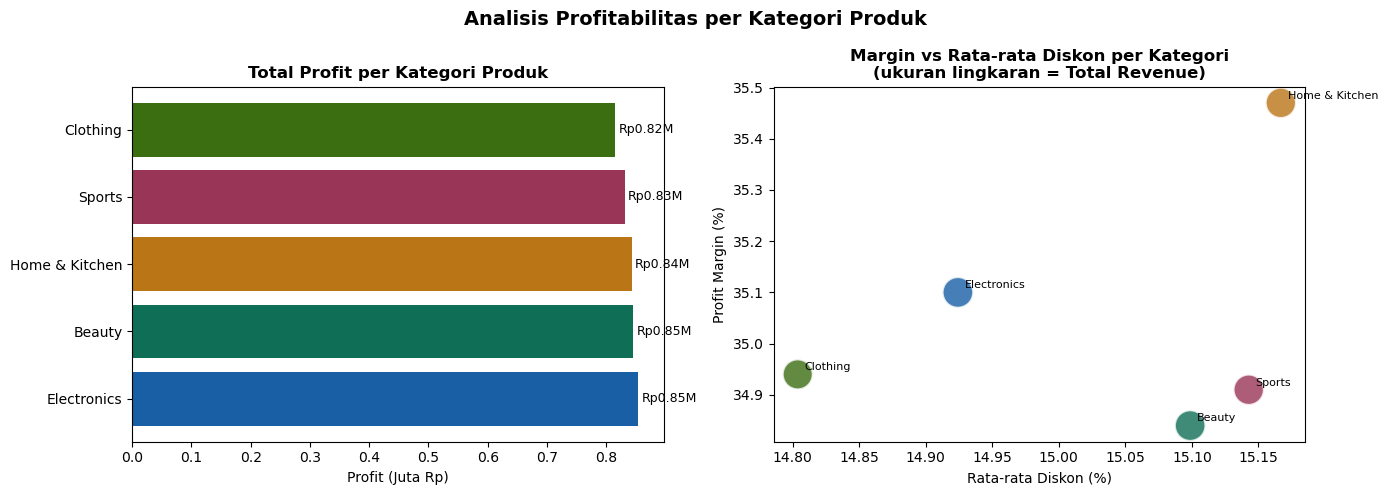

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cats = df_kategori['Product_Category']
colors_cat = ['#185FA5','#0F6E56','#BA7517','#993556','#3B6D11']

# Total Profit per Kategori
bars = axes[0].barh(cats, df_kategori['Total_Profit'] / 1e6, color=colors_cat)
axes[0].set_title('Total Profit per Kategori Produk', fontweight='bold')
axes[0].set_xlabel('Profit (Juta Rp)')
for bar, val in zip(bars, df_kategori['Total_Profit']):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'Rp{val/1e6:.2f}M', va='center', fontsize=9)

# Profit Margin vs Avg Discount (scatter)
axes[1].scatter(df_kategori['Avg_Discount'] * 100, df_kategori['Profit_Margin_%'],
                s=df_kategori['Total_Revenue'] / 5000, c=colors_cat, alpha=0.8, edgecolors='white', linewidth=1.5)
for i, row in df_kategori.iterrows():
    axes[1].annotate(row['Product_Category'],
                     (row['Avg_Discount']*100, row['Profit_Margin_%']),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
axes[1].set_title('Margin vs Rata-rata Diskon per Kategori\n(ukuran lingkaran = Total Revenue)', fontweight='bold')
axes[1].set_xlabel('Rata-rata Diskon (%)')
axes[1].set_ylabel('Profit Margin (%)')

plt.suptitle('Analisis Profitabilitas per Kategori Produk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


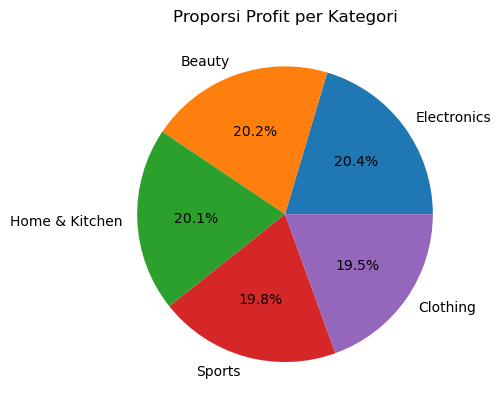

In [26]:
plt.pie(df_kategori['Total_Profit'], labels=df_kategori['Product_Category'], autopct='%1.1f%%')
plt.title('Proporsi Profit per Kategori')
plt.show()


### 6.3 Analisis per Customer Segment

In [21]:
df_segment = df.groupby('Customer_Segment').agg(
    Total_Revenue    = ('Revenue', 'sum'),
    Total_Profit     = ('Profit', 'sum'),
    Jumlah_Transaksi = ('Order_ID', 'count'),
    Avg_Order_Value  = ('Revenue', 'mean')
).reset_index()
df_segment['Profit_Margin_%'] = (df_segment['Total_Profit'] / df_segment['Total_Revenue'] * 100).round(2)
df_segment['Revenue_per_Transaksi'] = (df_segment['Total_Revenue'] / df_segment['Jumlah_Transaksi']).round(2)
df_segment = df_segment.sort_values('Total_Profit', ascending=False)
df_segment


,Customer_Segment,Total_Revenue,Total_Profit,Jumlah_Transaksi,Avg_Order_Value,Profit_Margin_%,Revenue_per_Transaksi
1,Corporate,3994927.24,1400460.21,3316,1204.742835,35.06,1204.74
2,Home Office,3979059.12,1396206.25,3389,1174.110097,35.09,1174.11
0,Consumer,3978433.12,1392831.22,3295,1207.415211,35.01,1207.42


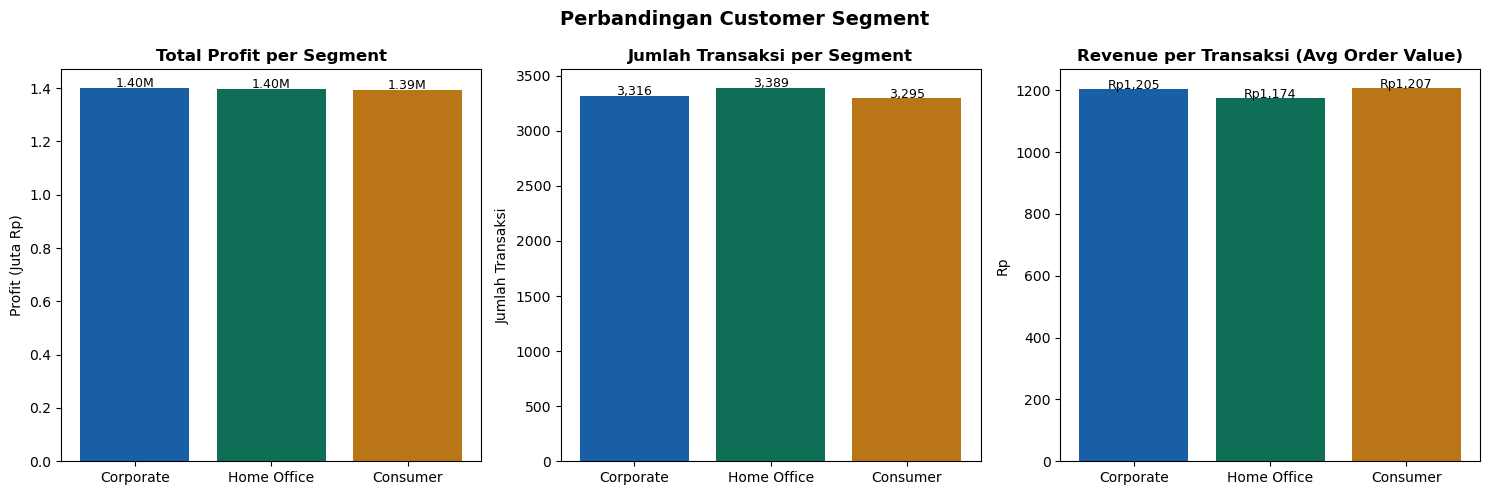

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
segs = df_segment['Customer_Segment']
colors_seg = ['#185FA5','#0F6E56','#BA7517']

axes[0].bar(segs, df_segment['Total_Profit'] / 1e6, color=colors_seg)
axes[0].set_title('Total Profit per Segment', fontweight='bold')
axes[0].set_ylabel('Profit (Juta Rp)')
for bar, val in zip(axes[0].patches, df_segment['Total_Profit']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val/1e6:.2f}M', ha='center', fontsize=9)

axes[1].bar(segs, df_segment['Jumlah_Transaksi'], color=colors_seg)
axes[1].set_title('Jumlah Transaksi per Segment', fontweight='bold')
axes[1].set_ylabel('Jumlah Transaksi')
for bar, val in zip(axes[1].patches, df_segment['Jumlah_Transaksi']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val:,}', ha='center', fontsize=9)

axes[2].bar(segs, df_segment['Revenue_per_Transaksi'], color=colors_seg)
axes[2].set_title('Revenue per Transaksi (Avg Order Value)', fontweight='bold')
axes[2].set_ylabel('Rp')
for bar, val in zip(axes[2].patches, df_segment['Revenue_per_Transaksi']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'Rp{val:,.0f}', ha='center', fontsize=9)

plt.suptitle('Perbandingan Customer Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.4 Analisis per Payment Method (Kolom yang Sebelumnya Tidak Dianalisis)

In [28]:
df_payment = df.groupby('Payment_Method').agg(
    Total_Revenue    = ('Revenue', 'sum'),
    Total_Profit     = ('Profit', 'sum'),
    Jumlah_Transaksi = ('Order_ID', 'count'),
    Avg_Order_Value  = ('Revenue', 'mean'),
    Avg_Discount     = ('Discount_Rate', 'mean')
).reset_index()
df_payment['Profit_Margin_%'] = (df_payment['Total_Profit'] / df_payment['Total_Revenue'] * 100).round(2)
df_payment = df_payment.sort_values('Total_Profit', ascending=False)
print("=== ANALISIS PER PAYMENT METHOD ===")
df_payment

=== ANALISIS PER PAYMENT METHOD ===


,Payment_Method,Total_Revenue,Total_Profit,Jumlah_Transaksi,Avg_Order_Value,Avg_Discount,Profit_Margin_%
2,Debit Card,2473292.21,859227.34,2074,1192.522763,0.150661,34.74
4,UPI,2402694.76,851559.69,2011,1194.776111,0.152123,35.44
0,Cash on Delivery,2412310.37,851024.82,2017,1195.989276,0.150580,35.28
1,Credit Card,2356673.37,826489.15,1963,1200.546801,0.147010,35.07
3,Net Banking,2307448.77,801196.68,1935,1192.479984,0.150920,34.72


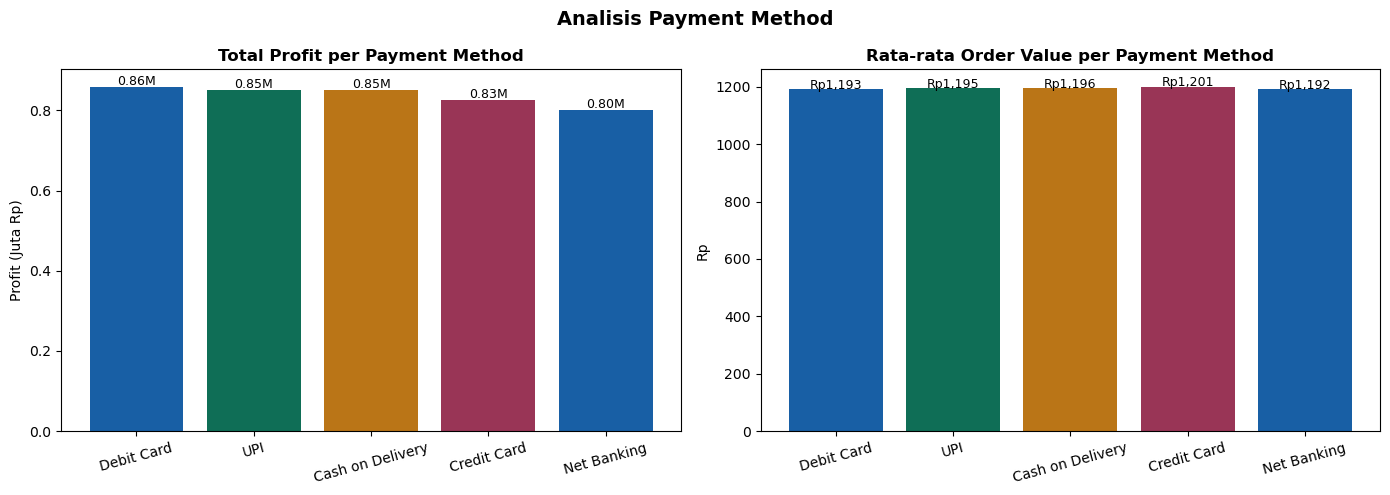

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_pay = len(df_payment)
colors_pay = ['#185FA5','#0F6E56','#BA7517','#993556'][:n_pay]

axes[0].bar(df_payment['Payment_Method'], df_payment['Total_Profit'] / 1e6, color=colors_pay)
axes[0].set_title('Total Profit per Payment Method', fontweight='bold')
axes[0].set_ylabel('Profit (Juta Rp)')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(axes[0].patches, df_payment['Total_Profit']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val/1e6:.2f}M', ha='center', fontsize=9)

axes[1].bar(df_payment['Payment_Method'], df_payment['Avg_Order_Value'], color=colors_pay)
axes[1].set_title('Rata-rata Order Value per Payment Method', fontweight='bold')
axes[1].set_ylabel('Rp')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(axes[1].patches, df_payment['Avg_Order_Value']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'Rp{val:,.0f}', ha='center', fontsize=9)

plt.suptitle('Analisis Payment Method', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Insight Payment Method:**

Analisis ini mengungkap perilaku pembayaran yang dapat menjadi dasar strategi promosi bertarget:
- Metode pembayaran dengan AOV (Average Order Value) tertinggi → kandidat untuk program cashback atau co-branding kartu.
- Metode dengan profit margin lebih rendah → kemungkinan digunakan bersama diskon lebih sering, perlu diinvestigasi.


### 6.5 Tren Bulanan Revenue & Profit

In [30]:
df_bulanan = df.groupby('Month').agg(
    Total_Revenue    = ('Revenue', 'sum'),
    Total_Profit     = ('Profit', 'sum'),
    Total_Transaksi  = ('Order_ID', 'count'),
    Avg_Discount     = ('Discount_Rate', 'mean')
).reset_index()
df_bulanan['Profit_Margin_%'] = (df_bulanan['Total_Profit'] / df_bulanan['Total_Revenue'] * 100).round(2)
df_bulanan['Month_Str'] = df_bulanan['Month'].astype(str).str[-2:]  # ambil bulan saja
bulan_label = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
df_bulanan['Bulan'] = bulan_label[:len(df_bulanan)]
df_bulanan


,Month,Total_Revenue,Total_Profit,Total_Transaksi,Avg_Discount,Profit_Margin_%,Month_Str,Bulan
0,2024-01,1030685.81,354992.57,863,0.153812,34.44,01,Jan
1,2024-02,953256.37,335792.53,790,0.150823,35.23,02,Feb
2,2024-03,992355.74,348601.80,872,0.149106,35.13,03,Mar
3,2024-04,979309.98,349341.45,822,0.148942,35.67,04,Apr
4,2024-05,1014429.28,364548.41,868,0.145864,35.94,05,Mei
5,2024-06,987704.04,344538.69,809,0.152905,34.88,06,Jun
6,2024-07,1049945.00,363909.01,850,0.151141,34.66,07,Jul
7,2024-08,996244.72,348482.05,834,0.148477,34.98,08,Agu
8,2024-09,1046701.70,366460.17,848,0.148467,35.01,09,Sep
9,2024-10,974671.96,343031.94,818,0.153557,35.19,10,Okt


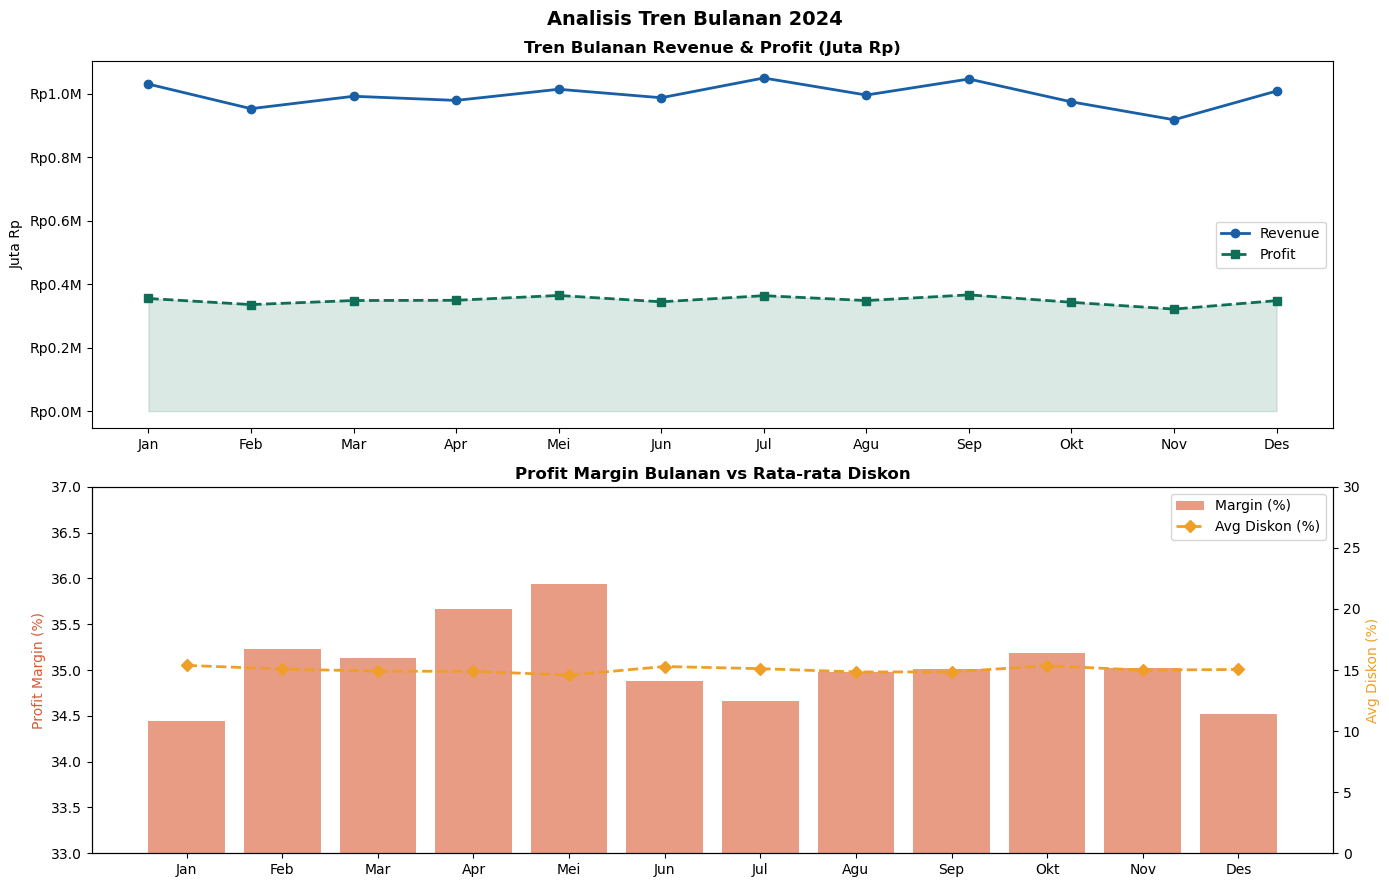

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
x = range(len(df_bulanan))

# Revenue vs Profit
axes[0].plot(x, df_bulanan['Total_Revenue']/1e6, 'o-', color='#185FA5', linewidth=2, label='Revenue')
axes[0].plot(x, df_bulanan['Total_Profit']/1e6, 's--', color='#0F6E56', linewidth=2, label='Profit')
axes[0].fill_between(x, df_bulanan['Total_Profit']/1e6, alpha=0.15, color='#0F6E56')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_bulanan['Bulan'])
axes[0].set_title('Tren Bulanan Revenue & Profit (Juta Rp)', fontweight='bold')
axes[0].set_ylabel('Juta Rp')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'Rp{v:.1f}M'))

# Profit Margin & Diskon bulanan
color_margin = '#D85A30'
color_diskon = '#EF9F27'
ax2 = axes[1].twinx()
bars = axes[1].bar(x, df_bulanan['Profit_Margin_%'], alpha=0.6, color=color_margin, label='Margin (%)')
ax2.plot(x, df_bulanan['Avg_Discount']*100, 'D--', color=color_diskon, linewidth=2, label='Avg Diskon (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_bulanan['Bulan'])
axes[1].set_title('Profit Margin Bulanan vs Rata-rata Diskon', fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)', color=color_margin)
ax2.set_ylabel('Avg Diskon (%)', color=color_diskon)
axes[1].set_ylim(33, 37)
ax2.set_ylim(0, 30)
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.suptitle('Analisis Tren Bulanan 2024', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.6 Analisis Diskon terhadap Profit

In [32]:
df_diskon = df.groupby('Discount_Category').agg(
    Rata_Profit       = ('Profit', 'mean'),
    Rata_Margin       = ('Margin_Profit', 'mean'),
    Total_Profit      = ('Profit', 'sum'),
    Jumlah_Transaksi  = ('Order_ID', 'count'),
    Avg_Discount_Rate = ('Discount_Rate', 'mean')
).reset_index()
df_diskon = df_diskon.sort_values('Avg_Discount_Rate')
print("=== ANALISIS KATEGORI DISKON ===")
df_diskon


=== ANALISIS KATEGORI DISKON ===


,Discount_Category,Rata_Profit,Rata_Margin,Total_Profit,Jumlah_Transaksi,Avg_Discount_Rate
1,Low (≤10%),461.683260,34.995117,1624201.71,3518,0.052928
2,Medium (10-20%),419.190376,34.920262,1383747.43,3301,0.155150
0,High (>20%),371.439340,35.131715,1181548.54,3181,0.252867


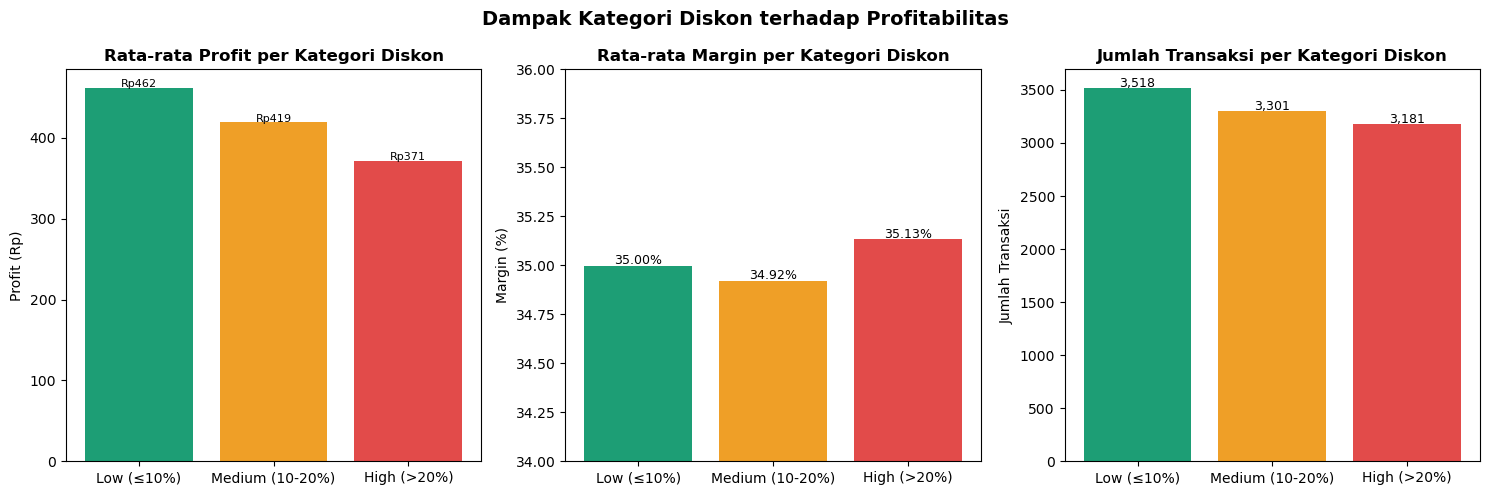

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cats_d = df_diskon['Discount_Category']
colors_d = ['#1D9E75','#EF9F27','#E24B4A']

axes[0].bar(cats_d, df_diskon['Rata_Profit'], color=colors_d)
axes[0].set_title('Rata-rata Profit per Kategori Diskon', fontweight='bold')
axes[0].set_ylabel('Profit (Rp)')
for bar, val in zip(axes[0].patches, df_diskon['Rata_Profit']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'Rp{val:,.0f}', ha='center', fontsize=8)

axes[1].bar(cats_d, df_diskon['Rata_Margin'], color=colors_d)
axes[1].set_title('Rata-rata Margin per Kategori Diskon', fontweight='bold')
axes[1].set_ylabel('Margin (%)')
axes[1].set_ylim(34, 36)
for bar, val in zip(axes[1].patches, df_diskon['Rata_Margin']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.2f}%', ha='center', fontsize=9)

axes[2].bar(cats_d, df_diskon['Jumlah_Transaksi'], color=colors_d)
axes[2].set_title('Jumlah Transaksi per Kategori Diskon', fontweight='bold')
axes[2].set_ylabel('Jumlah Transaksi')
for bar, val in zip(axes[2].patches, df_diskon['Jumlah_Transaksi']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val:,}', ha='center', fontsize=9)

plt.suptitle('Dampak Kategori Diskon terhadap Profitabilitas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


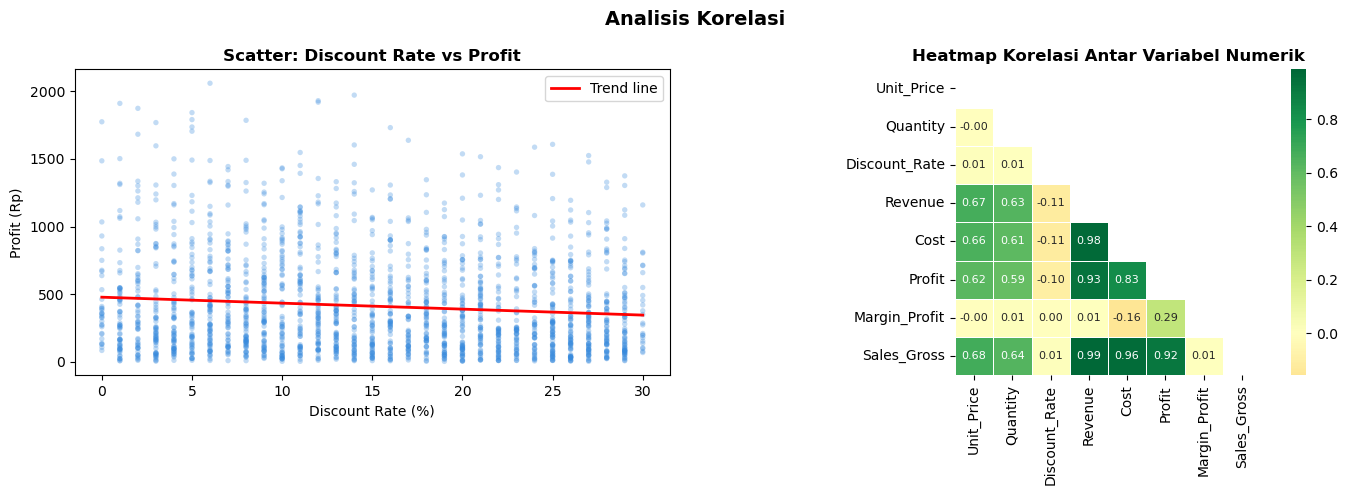

In [34]:
# Scatter plot Discount Rate vs Profit (sample 2000 titik agar tidak overplotting)
sample = df.sample(n=min(2000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample['Discount_Rate']*100, sample['Profit'],
                alpha=0.3, s=15, color='#378ADD', edgecolors='none')
z = np.polyfit(sample['Discount_Rate'], sample['Profit'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['Discount_Rate'].min(), sample['Discount_Rate'].max(), 100)
axes[0].plot(x_line*100, p(x_line), 'r-', linewidth=2, label='Trend line')
axes[0].set_xlabel('Discount Rate (%)')
axes[0].set_ylabel('Profit (Rp)')
axes[0].set_title('Scatter: Discount Rate vs Profit', fontweight='bold')
axes[0].legend()

# Heatmap korelasi
corr_cols = ['Unit_Price','Quantity','Discount_Rate','Revenue','Cost','Profit','Margin_Profit','Sales_Gross']
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', mask=mask,
            ax=axes[1], center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8})
axes[1].set_title('Heatmap Korelasi Antar Variabel Numerik', fontweight='bold')

plt.suptitle('Analisis Korelasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Analisis Customer: Repeat Purchase & CLV

In [35]:
# Frekuensi pembelian per customer
cust_freq = df.groupby('Customer_ID').agg(
    Jumlah_Order   = ('Order_ID', 'count'),
    Total_Revenue  = ('Revenue', 'sum'),
    Total_Profit   = ('Profit', 'sum'),
    Avg_Margin     = ('Margin_Profit', 'mean')
).reset_index()

# Klasifikasi customer
def klasifikasi_customer(n):
    if n == 1:
        return 'One-time'
    elif n <= 3:
        return 'Occasional (2-3x)'
    else:
        return 'Loyal (4x+)'

cust_freq['Customer_Type'] = cust_freq['Jumlah_Order'].apply(klasifikasi_customer)

print("=== DISTRIBUSI CUSTOMER BERDASARKAN FREKUENSI PEMBELIAN ===")
print(cust_freq['Customer_Type'].value_counts())
print(f"\nTotal unique customers: {len(cust_freq):,}")
print(f"Avg order per customer: {cust_freq['Jumlah_Order'].mean():.2f}")


=== DISTRIBUSI CUSTOMER BERDASARKAN FREKUENSI PEMBELIAN ===
Customer_Type
One-time             3248
Occasional (2-3x)    2502
Loyal (4x+)           244
Name: count, dtype: int64

Total unique customers: 5,994
Avg order per customer: 1.67


In [36]:
# CLV sederhana: Total Revenue / Total Customer × rata-rata bulan aktif
clv_by_type = cust_freq.groupby('Customer_Type').agg(
    Jumlah_Customer  = ('Customer_ID', 'count'),
    Avg_Revenue      = ('Total_Revenue', 'mean'),
    Avg_Profit       = ('Total_Profit', 'mean'),
    Avg_Orders       = ('Jumlah_Order', 'mean'),
    Avg_Margin       = ('Avg_Margin', 'mean')
).reset_index()
clv_by_type['Revenue_per_Order'] = (clv_by_type['Avg_Revenue'] / clv_by_type['Avg_Orders']).round(2)
print("=== CLV SEDERHANA PER TIPE CUSTOMER ===")
print(clv_by_type.to_string(index=False))


=== CLV SEDERHANA PER TIPE CUSTOMER ===
    Customer_Type  Jumlah_Customer  Avg_Revenue  Avg_Profit  Avg_Orders  Avg_Margin  Revenue_per_Order
      Loyal (4x+)              244  5085.848115 1762.999959    4.278689   34.553594            1188.65
Occasional (2-3x)             2502  2710.813058  954.525915    2.281375   35.094225            1188.24
         One-time             3248  1209.673113  422.137269    1.000000   35.061219            1209.67


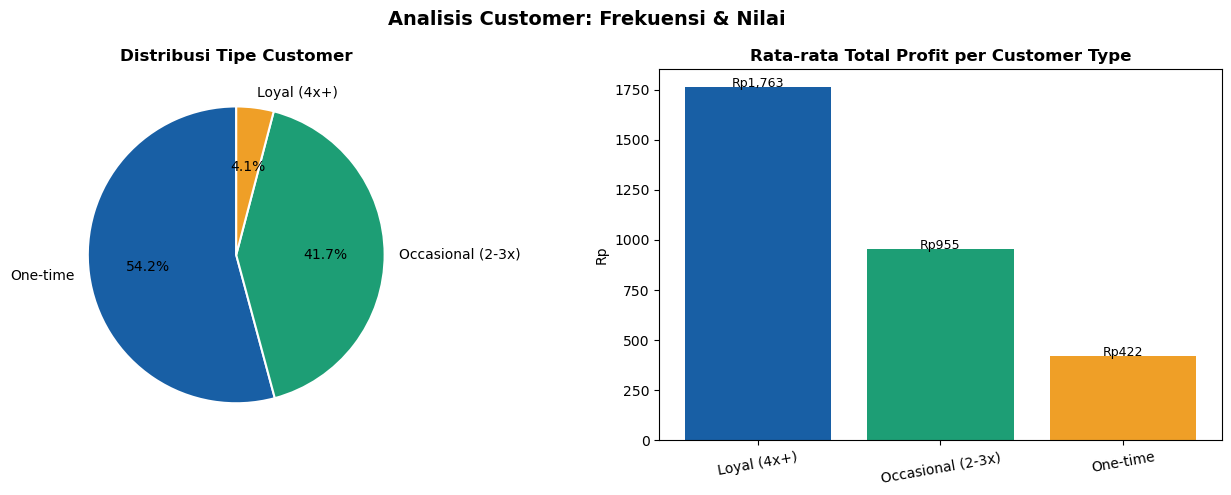

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribusi tipe customer
type_counts = cust_freq['Customer_Type'].value_counts()
axes[0].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%', colors=['#185FA5','#1D9E75','#EF9F27'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Distribusi Tipe Customer', fontweight='bold')

# Avg Profit per Customer Type
axes[1].bar(clv_by_type['Customer_Type'], clv_by_type['Avg_Profit'],
            color=['#185FA5','#1D9E75','#EF9F27'])
axes[1].set_title('Rata-rata Total Profit per Customer Type', fontweight='bold')
axes[1].set_ylabel('Rp')
axes[1].tick_params(axis='x', rotation=10)
for bar, val in zip(axes[1].patches, clv_by_type['Avg_Profit']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'Rp{val:,.0f}', ha='center', fontsize=9)

plt.suptitle('Analisis Customer: Frekuensi & Nilai', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Validasi Asumsi Statistik

> **Mengapa ini penting?** ANOVA mensyaratkan dua asumsi utama: (1) data tiap grup terdistribusi normal, dan (2) varians antar grup homogen (Levene's test). Mengabaikan ini membuat hasil ANOVA tidak dapat dipercaya.


### 8.1 Uji Normalitas (Shapiro-Wilk / Kolmogorov-Smirnov)

In [38]:
from scipy.stats import shapiro, kstest

print("=" * 60)
print("UJI NORMALITAS MARGIN_PROFIT PER REGION")
print("(Shapiro-Wilk jika n<5000; K-S jika n≥5000)")
print("=" * 60)

for region in df['Region'].unique():
    data = df[df['Region'] == region]['Margin_Profit'].dropna()
    if len(data) < 5000:
        stat, p = shapiro(data)
        metode = 'Shapiro-Wilk'
    else:
        stat, p = kstest(data, 'norm', args=(data.mean(), data.std()))
        metode = 'Kolmogorov-Smirnov'
    kesimpulan = "Normal ✓" if p > 0.05 else "TIDAK Normal ✗"
    print(f"  {region:6s} | {metode:20s} | stat={stat:.4f} | p={p:.4f} | {kesimpulan}")

print()
print("=" * 60)
print("UJI NORMALITAS MARGIN_PROFIT PER KATEGORI PRODUK")
print("=" * 60)
for cat in df['Product_Category'].unique():
    data = df[df['Product_Category'] == cat]['Margin_Profit'].dropna()
    if len(data) < 5000:
        stat, p = shapiro(data)
        metode = 'Shapiro-Wilk'
    else:
        stat, p = kstest(data, 'norm', args=(data.mean(), data.std()))
        metode = 'Kolmogorov-Smirnov'
    kesimpulan = "Normal ✓" if p > 0.05 else "TIDAK Normal ✗"
    print(f"  {cat:20s} | {metode:20s} | stat={stat:.4f} | p={p:.4f} | {kesimpulan}")


UJI NORMALITAS MARGIN_PROFIT PER REGION
(Shapiro-Wilk jika n<5000; K-S jika n≥5000)
  North  | Shapiro-Wilk         | stat=0.9548 | p=0.0000 | TIDAK Normal ✗
  South  | Shapiro-Wilk         | stat=0.9543 | p=0.0000 | TIDAK Normal ✗
  West   | Shapiro-Wilk         | stat=0.9529 | p=0.0000 | TIDAK Normal ✗
  East   | Shapiro-Wilk         | stat=0.9550 | p=0.0000 | TIDAK Normal ✗

UJI NORMALITAS MARGIN_PROFIT PER KATEGORI PRODUK
  Clothing             | Shapiro-Wilk         | stat=0.9524 | p=0.0000 | TIDAK Normal ✗
  Beauty               | Shapiro-Wilk         | stat=0.9528 | p=0.0000 | TIDAK Normal ✗
  Sports               | Shapiro-Wilk         | stat=0.9593 | p=0.0000 | TIDAK Normal ✗
  Home & Kitchen       | Shapiro-Wilk         | stat=0.9510 | p=0.0000 | TIDAK Normal ✗
  Electronics          | Shapiro-Wilk         | stat=0.9555 | p=0.0000 | TIDAK Normal ✗


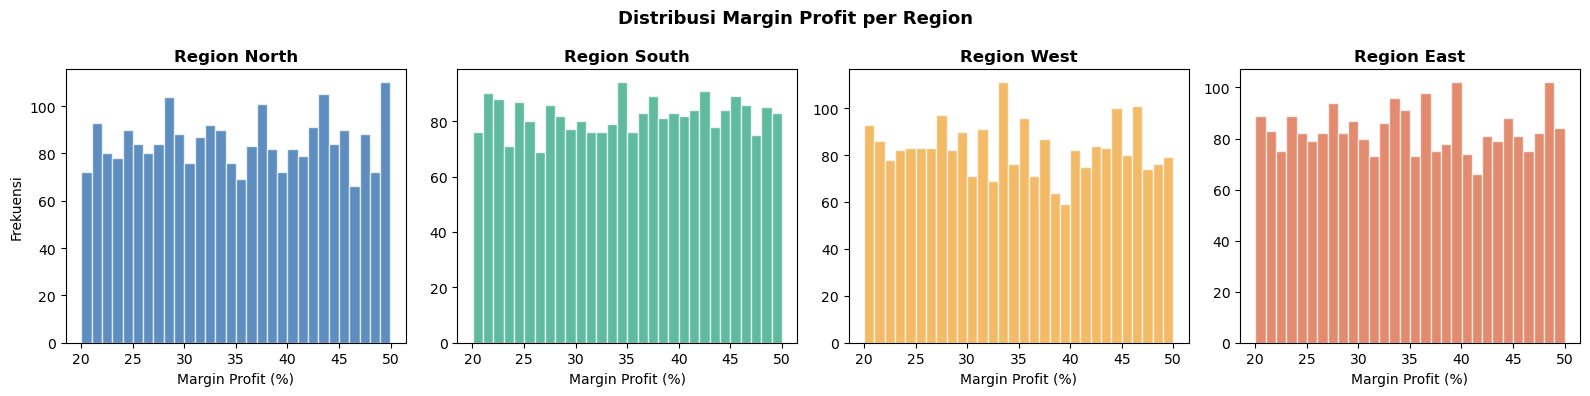

In [39]:
# Visualisasi distribusi Margin_Profit per Region
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
regions = df['Region'].unique()
palette = ['#185FA5','#1D9E75','#EF9F27','#D85A30']

for i, (region, color) in enumerate(zip(regions, palette)):
    data = df[df['Region'] == region]['Margin_Profit']
    axes[i].hist(data, bins=30, color=color, alpha=0.7, edgecolor='white')
    axes[i].set_title(f'Region {region}', fontweight='bold')
    axes[i].set_xlabel('Margin Profit (%)')
    if i == 0:
        axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Margin Profit per Region', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 8.2 Uji Homogenitas Varians (Levene's Test)

In [40]:
from scipy.stats import levene

print("=== LEVENE'S TEST — HOMOGENITAS VARIANS ===")
print()

# Per Region
region_groups = [df[df['Region'] == r]['Margin_Profit'].dropna() for r in df['Region'].unique()]
stat, p = levene(*region_groups)
print(f"Region      : Levene stat={stat:.4f}, p={p:.4f}  →  {'Varians Homogen ✓' if p>0.05 else 'Varians TIDAK Homogen ✗'}")

# Per Kategori
cat_groups = [df[df['Product_Category'] == c]['Margin_Profit'].dropna() for c in df['Product_Category'].unique()]
stat, p = levene(*cat_groups)
print(f"Kategori    : Levene stat={stat:.4f}, p={p:.4f}  →  {'Varians Homogen ✓' if p>0.05 else 'Varians TIDAK Homogen ✗'}")

# Per Segment
seg_groups = [df[df['Customer_Segment'] == s]['Margin_Profit'].dropna() for s in df['Customer_Segment'].unique()]
stat, p = levene(*seg_groups)
print(f"Segment     : Levene stat={stat:.4f}, p={p:.4f}  →  {'Varians Homogen ✓' if p>0.05 else 'Varians TIDAK Homogen ✗'}")

print()
print("Catatan: Jika varians tidak homogen, gunakan Welch ANOVA (scipy.stats.f_oneway dengan equal_var=False")
print("         atau gunakan Kruskal-Wallis sebagai alternatif non-parametrik.)")


=== LEVENE'S TEST — HOMOGENITAS VARIANS ===

Region      : Levene stat=0.0589, p=0.9813  →  Varians Homogen ✓
Kategori    : Levene stat=1.2871, p=0.2725  →  Varians Homogen ✓
Segment     : Levene stat=1.2909, p=0.2751  →  Varians Homogen ✓

Catatan: Jika varians tidak homogen, gunakan Welch ANOVA (scipy.stats.f_oneway dengan equal_var=False
         atau gunakan Kruskal-Wallis sebagai alternatif non-parametrik.)


## 9. Uji Hipotesis

### Hipotesis 1 — Perbedaan Margin Profit antar Region

**H₀**: Tidak ada perbedaan rata-rata margin profit antar Region  
**H₁**: Ada perbedaan rata-rata margin profit antar Region  
*Uji: One-Way ANOVA*


In [41]:
from scipy.stats import f_oneway

groups_region = [df[df['Region'] == r]['Margin_Profit'].dropna() for r in df['Region'].unique()]
f_stat, p_val = f_oneway(*groups_region)

print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {p_val:.4f}")
print()
if p_val < 0.05:
    print("Kesimpulan: TOLAK H₀ → Ada perbedaan signifikan margin profit antar Region.")
    print("           Perlu post-hoc test (Tukey HSD) untuk menentukan region mana yang berbeda.")
else:
    print("Kesimpulan: TERIMA H₀ → Tidak ada perbedaan signifikan margin profit antar Region.")
    print("           Implikasi: semua region beroperasi dengan efisiensi yang setara.")
    print("           CATATAN: Rekomendasi 'replikasi strategi North' TIDAK didukung data ini.")


F-Statistic : 0.5591
P-Value     : 0.6420

Kesimpulan: TERIMA H₀ → Tidak ada perbedaan signifikan margin profit antar Region.
           Implikasi: semua region beroperasi dengan efisiensi yang setara.
           CATATAN: Rekomendasi 'replikasi strategi North' TIDAK didukung data ini.


### Hipotesis 2 — Perbedaan Margin Profit antar Kategori Produk

**H₀**: Tidak ada perbedaan rata-rata margin profit antar Kategori Produk  
**H₁**: Ada perbedaan rata-rata margin profit antar Kategori Produk  
*Uji: One-Way ANOVA*


In [42]:
groups_cat = [df[df['Product_Category'] == c]['Margin_Profit'].dropna() for c in df['Product_Category'].unique()]
f_stat, p_val = f_oneway(*groups_cat)

print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {p_val:.4f}")
print()
if p_val < 0.05:
    print("Kesimpulan: TOLAK H₀ → Ada kategori dengan efisiensi margin yang secara signifikan berbeda.")
else:
    print("Kesimpulan: TERIMA H₀ → Semua kategori produk memiliki efisiensi margin yang serupa.")
    print("           Implikasi: perbedaan strategi antar kategori harus didasarkan pada volume & AOV,")
    print("           bukan margin, karena margin-nya tidak berbeda signifikan.")


F-Statistic : 0.3887
P-Value     : 0.8169

Kesimpulan: TERIMA H₀ → Semua kategori produk memiliki efisiensi margin yang serupa.
           Implikasi: perbedaan strategi antar kategori harus didasarkan pada volume & AOV,
           bukan margin, karena margin-nya tidak berbeda signifikan.


### Hipotesis 3 — Perbedaan Margin Profit antar Customer Segment

**H₀**: Tidak ada perbedaan rata-rata margin profit antar Customer Segment  
**H₁**: Ada perbedaan rata-rata margin profit antar Customer Segment  
*Uji: One-Way ANOVA*


In [43]:
groups_seg = [df[df['Customer_Segment'] == s]['Margin_Profit'].dropna() for s in df['Customer_Segment'].unique()]
f_stat, p_val = f_oneway(*groups_seg)

print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {p_val:.4f}")
print()
if p_val < 0.05:
    print("Kesimpulan: TOLAK H₀ → Ada perbedaan margin profit antar Customer Segment.")
else:
    print("Kesimpulan: TERIMA H₀ → Semua segment memiliki margin yang hampir sama.")
    print("           Implikasi: strategi peningkatan margin tidak bisa hanya menyasar satu segment.")
    print("           Fokus ke optimasi harga & diskon secara keseluruhan.")


F-Statistic : 0.7656
P-Value     : 0.4651

Kesimpulan: TERIMA H₀ → Semua segment memiliki margin yang hampir sama.
           Implikasi: strategi peningkatan margin tidak bisa hanya menyasar satu segment.
           Fokus ke optimasi harga & diskon secara keseluruhan.


### Hipotesis 4 — Hubungan antara Diskon dan Profit

**H₀**: Tidak ada hubungan linear antara besaran diskon dan profit  
**H₁**: Terdapat hubungan negatif yang signifikan antara diskon dan profit  
*Uji: Pearson Correlation Test*


In [44]:
from scipy.stats import pearsonr

corr, p_val = pearsonr(df['Discount_Rate'], df['Profit'])

print(f"Koefisien Korelasi (r) : {corr:.4f}")
print(f"P-Value                : {p_val:.4e}")
print()
if p_val < 0.05:
    arah     = 'negatif (diskon ↑ → profit ↓)' if corr < 0 else 'positif'
    kekuatan = 'sangat lemah' if abs(corr) < 0.1 else ('lemah' if abs(corr) < 0.3 else ('sedang' if abs(corr) < 0.7 else 'kuat'))
    print(f"Kesimpulan  : TOLAK H₀ → Ada hubungan {arah}")
    print(f"Kekuatan    : {kekuatan} (|r| = {abs(corr):.4f})")
    print()
    print("Interpretasi bisnis:")
    print("  • Diskon memang menekan profit, tapi pengaruhnya kecil (|r| << 0.3).")
    print("  • Artinya ADA faktor lain yang jauh lebih dominan terhadap profit:")
    print("    → Unit Price, Quantity sold, Cost structure.")
    print("  • Strategi: jangan hanya fokus memotong diskon —")
    print("    optimalkan HARGA JUAL dan EFISIENSI BIAYA secara bersamaan.")
else:
    print("Kesimpulan: TERIMA H₀. Diskon tidak memengaruhi profit secara signifikan.")


Koefisien Korelasi (r) : -0.1040
P-Value                : 1.9676e-25

Kesimpulan  : TOLAK H₀ → Ada hubungan negatif (diskon ↑ → profit ↓)
Kekuatan    : lemah (|r| = 0.1040)

Interpretasi bisnis:
  • Diskon memang menekan profit, tapi pengaruhnya kecil (|r| << 0.3).
  • Artinya ADA faktor lain yang jauh lebih dominan terhadap profit:
    → Unit Price, Quantity sold, Cost structure.
  • Strategi: jangan hanya fokus memotong diskon —
    optimalkan HARGA JUAL dan EFISIENSI BIAYA secara bersamaan.


## 10. Identifikasi Inefisiensi Bisnis & Cara Mengatasinya

> Bagian ini menggabungkan seluruh temuan analisis menjadi identifikasi masalah konkret beserta solusi actionable yang dapat langsung dieksekusi manajemen.


### 10.1 Inefisiensi #1 — Diskon Tidak Terkontrol

**Temuan:**
- Rata-rata diskon 15.1%, namun ada 3.181 transaksi dengan diskon >20% (High category)
- Transaksi High Discount menghasilkan rata-rata profit LEBIH RENDAH dibanding Low Discount
- Korelasi negatif signifikan antara diskon dan profit (walaupun lemah, secara absolut tetap merugikan)


In [45]:
# Kuantifikasi kerugian akibat diskon tinggi
df_high  = df[df['Discount_Category'] == 'High (>20%)']
df_low   = df[df['Discount_Category'] == 'Low (≤10%)']

selisih_profit_per_trx = df_low['Profit'].mean() - df_high['Profit'].mean()
estimasi_kerugian_high = selisih_profit_per_trx * len(df_high)

print("=== KUANTIFIKASI DAMPAK DISKON TINGGI ===")
print(f"Rata-rata Profit transaksi Low Discount   : Rp {df_low['Profit'].mean():,.2f}")
print(f"Rata-rata Profit transaksi High Discount  : Rp {df_high['Profit'].mean():,.2f}")
print(f"Selisih per transaksi                     : Rp {selisih_profit_per_trx:,.2f}")
print(f"Jumlah transaksi High Discount            : {len(df_high):,}")
print(f"Estimasi opportunity loss dari high disc. : Rp {estimasi_kerugian_high:,.2f}")
print()
print("REKOMENDASI ACTIONABLE:")
print("  1. Terapkan Discount Cap Policy: diskon >15% wajib approval manajer.")
print("  2. Buat tiered discount schedule per kategori produk berdasarkan margin aktual.")
print("  3. Ganti diskon langsung dengan value-add (gift, bundling) untuk mempertahankan AOV.")
print("  4. Pasang alert otomatis di sistem POS jika diskon melebihi threshold.")


=== KUANTIFIKASI DAMPAK DISKON TINGGI ===
Rata-rata Profit transaksi Low Discount   : Rp 461.68
Rata-rata Profit transaksi High Discount  : Rp 371.44
Selisih per transaksi                     : Rp 90.24
Jumlah transaksi High Discount            : 3,181
Estimasi opportunity loss dari high disc. : Rp 287,065.91

REKOMENDASI ACTIONABLE:
  1. Terapkan Discount Cap Policy: diskon >15% wajib approval manajer.
  2. Buat tiered discount schedule per kategori produk berdasarkan margin aktual.
  3. Ganti diskon langsung dengan value-add (gift, bundling) untuk mempertahankan AOV.
  4. Pasang alert otomatis di sistem POS jika diskon melebihi threshold.


### 10.2 Inefisiensi #2 — Revenue Tinggi Tidak Selalu Menghasilkan Profit Optimal

**Temuan:**
- Electronics punya total revenue tertinggi, tetapi margin-nya tidak lebih baik dari kategori lain
- Perbedaan margin antar kategori tidak signifikan secara statistik (H₂ diterima)
- Artinya biaya COGS (Cost of Goods Sold) dan diskon di Electronics menyerap keuntungan dari volume tinggi


In [46]:
# Analisis efisiensi per kategori
df_eff = df.groupby('Product_Category').agg(
    Total_Revenue = ('Revenue', 'sum'),
    Total_Cost    = ('Cost', 'sum'),
    Total_Profit  = ('Profit', 'sum'),
    Avg_Discount  = ('Discount_Rate', 'mean'),
    N_Transaksi   = ('Order_ID', 'count')
).reset_index()
df_eff['Margin_%']        = (df_eff['Total_Profit'] / df_eff['Total_Revenue'] * 100).round(2)
df_eff['Cost_Ratio_%']    = (df_eff['Total_Cost']   / df_eff['Total_Revenue'] * 100).round(2)
df_eff['Profit_per_Trx']  = (df_eff['Total_Profit'] / df_eff['N_Transaksi']).round(2)
df_eff = df_eff.sort_values('Margin_%', ascending=False)

print("=== EFISIENSI PER KATEGORI PRODUK ===")
print(df_eff[['Product_Category','Margin_%','Cost_Ratio_%','Avg_Discount','Profit_per_Trx']].to_string(index=False))
print()
print("REKOMENDASI ACTIONABLE:")
print("  1. Untuk kategori dengan Cost_Ratio tinggi: negosiasi ulang harga beli dari supplier.")
print("  2. Untuk Electronics: kurangi intensitas promo/diskon, fokus pada upsell aksesoris (margin lebih tinggi).")
print("  3. Kembangkan kategori dengan Profit_per_Trx tinggi sebagai kategori unggulan.")
print("  4. Lakukan product mix analysis: kurangi SKU dengan margin < rata-rata industri.")


=== EFISIENSI PER KATEGORI PRODUK ===
Product_Category  Margin_%  Cost_Ratio_%  Avg_Discount  Profit_per_Trx
  Home & Kitchen     35.47         64.53      0.151668          419.85
     Electronics     35.10         64.90      0.149242          429.02
        Clothing     34.94         65.06      0.148038          406.09
          Sports     34.91         65.09      0.151427          416.16
          Beauty     34.84         65.16      0.150987          423.73

REKOMENDASI ACTIONABLE:
  1. Untuk kategori dengan Cost_Ratio tinggi: negosiasi ulang harga beli dari supplier.
  2. Untuk Electronics: kurangi intensitas promo/diskon, fokus pada upsell aksesoris (margin lebih tinggi).
  3. Kembangkan kategori dengan Profit_per_Trx tinggi sebagai kategori unggulan.
  4. Lakukan product mix analysis: kurangi SKU dengan margin < rata-rata industri.


### 10.3 Inefisiensi #3 — Performa Region yang Sebenarnya Setara

**Temuan:**
- ANOVA menunjukkan tidak ada perbedaan signifikan margin antar Region (H₁ diterima)
- North unggul dalam total profit BUKAN karena efisiensi lebih tinggi, melainkan karena volume transaksi lebih banyak
- Rekomendasi awal "replikasi strategi North" tidak valid karena tidak ada bukti strategi berbeda


In [47]:
# Analisis lebih dalam: kenapa North punya profit lebih tinggi?
df_region_detail = df.groupby('Region').agg(
    N_Transaksi   = ('Order_ID', 'count'),
    Avg_Revenue   = ('Revenue', 'mean'),
    Avg_Profit    = ('Profit', 'mean'),
    Avg_Qty       = ('Quantity', 'mean'),
    Avg_Discount  = ('Discount_Rate', 'mean'),
    Total_Profit  = ('Profit', 'sum')
).reset_index()
df_region_detail['Profit_per_Trx'] = (df_region_detail['Total_Profit'] / df_region_detail['N_Transaksi']).round(2)
df_region_detail = df_region_detail.sort_values('Total_Profit', ascending=False)

print("=== ANALISIS MENDALAM PERFORMA REGION ===")
print(df_region_detail[['Region','N_Transaksi','Avg_Revenue','Avg_Profit','Avg_Discount','Profit_per_Trx']].to_string(index=False))
print()
print("REKOMENDASI ACTIONABLE (Revisi — berbasis bukti data):")
print("  1. Fokus bukan pada 'replikasi strategi North', tapi pada PENINGKATAN VOLUME TRANSAKSI")
print("     di region dengan jumlah transaksi lebih sedikit (South, West).")
print("  2. Investasikan pada acquisition campaign di region South untuk meningkatkan jumlah order.")
print("  3. Pantau Avg Discount per Region — region dengan diskon lebih tinggi berpotensi menekan margin.")
print("  4. Standarisasi SOP pricing dan promosi agar semua region beroperasi pada level efisiensi sama.")


=== ANALISIS MENDALAM PERFORMA REGION ===
Region  N_Transaksi  Avg_Revenue  Avg_Profit  Avg_Discount  Profit_per_Trx
 North         2548  1192.398803  419.359388      0.150965          419.36
  East         2506  1192.275219  418.776141      0.151373          418.78
  West         2486  1200.205020  418.554928      0.147643          418.55
 South         2460  1196.193476  419.101382      0.151089          419.10

REKOMENDASI ACTIONABLE (Revisi — berbasis bukti data):
  1. Fokus bukan pada 'replikasi strategi North', tapi pada PENINGKATAN VOLUME TRANSAKSI
     di region dengan jumlah transaksi lebih sedikit (South, West).
  2. Investasikan pada acquisition campaign di region South untuk meningkatkan jumlah order.
  3. Pantau Avg Discount per Region — region dengan diskon lebih tinggi berpotensi menekan margin.
  4. Standarisasi SOP pricing dan promosi agar semua region beroperasi pada level efisiensi sama.


### 10.4 Inefisiensi #4 — Customer Segmentasi Belum Dioptimalkan untuk Retensi

**Temuan:**
- Perbedaan profit antar segment hanya ~0.1% (tidak signifikan secara statistik)
- Belum ada analisis repeat purchase — padahal customer loyal lebih murah untuk dipertahankan daripada akuisisi baru
- Corporate segment punya jumlah transaksi lebih sedikit tapi bisa memiliki AOV lebih tinggi


In [48]:
# Analisis repeat purchase per segment
cust_seg = df.groupby(['Customer_ID','Customer_Segment']).agg(
    Jumlah_Order  = ('Order_ID', 'count'),
    Total_Revenue = ('Revenue', 'sum'),
    Total_Profit  = ('Profit', 'sum')
).reset_index()

repeat_seg = cust_seg[cust_seg['Jumlah_Order'] > 1].groupby('Customer_Segment').agg(
    Repeat_Customers = ('Customer_ID', 'count'),
    Avg_Revenue      = ('Total_Revenue', 'mean'),
    Avg_Profit       = ('Total_Profit', 'mean')
).reset_index()

all_seg_count = cust_seg.groupby('Customer_Segment')['Customer_ID'].count().reset_index(name='Total_Customers')
repeat_seg = repeat_seg.merge(all_seg_count, on='Customer_Segment')
repeat_seg['Repeat_Rate_%'] = (repeat_seg['Repeat_Customers'] / repeat_seg['Total_Customers'] * 100).round(1)

print("=== REPEAT PURCHASE RATE PER SEGMENT ===")
print(repeat_seg[['Customer_Segment','Total_Customers','Repeat_Customers','Repeat_Rate_%','Avg_Revenue','Avg_Profit']].to_string(index=False))
print()
print("REKOMENDASI ACTIONABLE:")
print("  1. Buat program loyalty tier (Bronze/Silver/Gold) yang memberikan benefit nyata.")
print("  2. Untuk Corporate: tawarkan kontrak volume tahunan dengan harga terjamin (lock-in revenue).")
print("  3. Kirim campaign email/notifikasi personal berbasis purchase history (personalized retargeting).")
print("  4. Identifikasi customer one-time dengan total spend tinggi → prioritaskan untuk win-back campaign.")


=== REPEAT PURCHASE RATE PER SEGMENT ===
Customer_Segment  Total_Customers  Repeat_Customers  Repeat_Rate_%  Avg_Revenue  Avg_Profit
        Consumer             2775               462           16.6  2541.441861  886.750996
       Corporate             2778               458           16.5  2608.276332  921.581921
     Home Office             2793               521           18.7  2560.361305  894.912802

REKOMENDASI ACTIONABLE:
  1. Buat program loyalty tier (Bronze/Silver/Gold) yang memberikan benefit nyata.
  2. Untuk Corporate: tawarkan kontrak volume tahunan dengan harga terjamin (lock-in revenue).
  3. Kirim campaign email/notifikasi personal berbasis purchase history (personalized retargeting).
  4. Identifikasi customer one-time dengan total spend tinggi → prioritaskan untuk win-back campaign.


### 10.5 Inefisiensi #5 — Pola Musiman Tidak Dimanfaatkan

**Temuan:**
- Ada fluktuasi profit margin bulanan (34.44% di Januari vs 35.94% di Mei)
- Bulan dengan revenue tinggi belum tentu memiliki margin optimal (kemungkinan karena diskon musiman)
- Belum ada strategi berbeda untuk bulan peak vs off-peak


In [49]:
# Analisis seasonality per kuartal
df_quarter = df.groupby('Quarter').agg(
    Total_Revenue   = ('Revenue', 'sum'),
    Total_Profit    = ('Profit', 'sum'),
    Avg_Discount    = ('Discount_Rate', 'mean'),
    N_Transaksi     = ('Order_ID', 'count')
).reset_index()
df_quarter['Profit_Margin_%'] = (df_quarter['Total_Profit'] / df_quarter['Total_Revenue'] * 100).round(2)
df_quarter['Quarter_Label']   = df_quarter['Quarter'].map({1:'Q1 (Jan-Mar)',2:'Q2 (Apr-Jun)',3:'Q3 (Jul-Sep)',4:'Q4 (Okt-Des)'})

print("=== ANALISIS PER KUARTAL ===")
print(df_quarter[['Quarter_Label','Total_Revenue','Total_Profit','Profit_Margin_%','Avg_Discount','N_Transaksi']].to_string(index=False))
print()

# Bulan terbaik dan terburuk
best_month  = df_bulanan.loc[df_bulanan['Profit_Margin_%'].idxmax(), 'Bulan'] if 'Bulan' in df_bulanan.columns else 'N/A'
worst_month = df_bulanan.loc[df_bulanan['Profit_Margin_%'].idxmin(), 'Bulan'] if 'Bulan' in df_bulanan.columns else 'N/A'
print(f"Bulan dengan margin tertinggi : {best_month}")
print(f"Bulan dengan margin terendah  : {worst_month}")
print()
print("REKOMENDASI ACTIONABLE:")
print("  1. Kuartal dengan diskon rata-rata tinggi → review apakah promosi saat itu profitable.")
print("  2. Pada bulan off-peak: dorong penjualan lewat bundling atau program referral, BUKAN diskon.")
print("  3. Pada bulan peak: kurangi diskon — customer akan tetap beli. Margin lebih sehat.")
print("  4. Susun annual promo calendar berbasis data historis ini agar promosi lebih strategis.")


=== ANALISIS PER KUARTAL ===
Quarter_Label  Total_Revenue  Total_Profit  Profit_Margin_%  Avg_Discount  N_Transaksi
 Q1 (Jan-Mar)     2976297.92    1039386.90            34.92      0.151251         2525
 Q2 (Apr-Jun)     2981443.30    1058428.55            35.50      0.149156         2499
 Q3 (Jul-Sep)     3092891.42    1078851.23            34.88      0.149368         2532
 Q4 (Okt-Des)     2901786.84    1012831.00            34.90      0.151338         2444

Bulan dengan margin tertinggi : Mei
Bulan dengan margin terendah  : Jan

REKOMENDASI ACTIONABLE:
  1. Kuartal dengan diskon rata-rata tinggi → review apakah promosi saat itu profitable.
  2. Pada bulan off-peak: dorong penjualan lewat bundling atau program referral, BUKAN diskon.
  3. Pada bulan peak: kurangi diskon — customer akan tetap beli. Margin lebih sehat.
  4. Susun annual promo calendar berbasis data historis ini agar promosi lebih strategis.


## 11. Ringkasan Kesimpulan & Rekomendasi Strategis

### Temuan Utama

| # | Area | Temuan | Status Signifikansi |
|---|------|--------|---------------------|
| 1 | Diskon | Korelasi negatif diskon–profit signifikan, kekuatan lemah (r=−0.10) | ✅ Signifikan (p<0.05) |
| 2 | Region | Tidak ada perbedaan margin antar region yang signifikan | ❌ Tidak signifikan |
| 3 | Kategori | Tidak ada perbedaan efisiensi margin antar kategori | ❌ Tidak signifikan |
| 4 | Segment | Tidak ada perbedaan margin antar customer segment | ❌ Tidak signifikan |
| 5 | Payment | Belum dianalisis sebelumnya — perlu investigasi lebih lanjut | 🔍 Baru dianalisis |

### Rekomendasi Strategis (Prioritas Eksekusi)

**🔴 Prioritas Tinggi — Eksekusi dalam 30 hari:**
1. **Terapkan Discount Cap Policy**: Batas maksimal diskon 15% tanpa approval; >15% wajib persetujuan manajer senior
2. **Perbaiki Sistem POS**: Tambahkan guardrail otomatis untuk mencegah transaksi dengan margin negatif
3. **Audit SKU merugi**: Identifikasi dan hentikan diskon pada produk yang sudah margin tipis

**🟡 Prioritas Menengah — Eksekusi dalam 90 hari:**
4. **Program loyalty berbasis data**: Tier Bronze/Silver/Gold dengan benefit nyata bagi repeat customer
5. **Negosiasi ulang kontrak supplier**: Terutama untuk kategori dengan Cost Ratio tertinggi
6. **Annual promo calendar**: Susun jadwal promosi setahun berbasis data seasonality 2024

**🟢 Prioritas Jangka Panjang — Eksekusi dalam 6 bulan:**
7. **Ekspansi volume di region South & West**: Campaign akuisisi pelanggan baru, bukan efisiensi (karena margin sudah setara)
8. **Corporate contract program**: Kontrak volume tahunan untuk segment Corporate guna mengunci revenue
9. **Personalized retargeting**: Sistem rekomendasi produk berbasis purchase history per customer


## 12. Target Audiens Laporan

**Pihak yang dimaksud — Manajemen tingkat atas ritel:**

- **CEO / Direktur Utama**: Fokus pada ringkasan profit, margin trend, dan rekomendasi strategis jangka panjang
- **CFO / Direktur Keuangan**: Fokus pada cost ratio, opportunity loss dari diskon tinggi, dan estimasi dampak finansial rekomendasi
- **CMO / Direktur Pemasaran**: Fokus pada efektivitas diskon, segmentasi pelanggan, dan promo calendar
- **COO / Direktur Operasional**: Fokus pada performa region, standardisasi SOP, dan sistem guardrail POS
- **Head of Analytics**: Fokus pada validasi metodologi, uji asumsi statistik, dan kualitas data untuk pengambilan keputusan
